# Day 1 - Week 4: Hands-On Lab

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## Load the Week 3 Titanic Dataset

I will use the Titanic dataset from Week 3.

The target column is:

`Survived`

To keep the notebook focused on **Train / Validation / Test splits**, I will use a small group of useful features and handle missing/categorical values using a preprocessing pipeline.

In [2]:
df = pd.read_csv("../../week1/day4/train.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Handle Missing Values

`Age` contains missing values, so I fill them using the mean age.

`Embarked` can also contain missing values, so I fill them using the most common value.

In [3]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

### Convert Categorical Columns to Numbers

Machine-learning models need numerical input.

The Titanic dataset contains categorical columns such as:

- `Sex`
- `Embarked`

I will convert them using `pd.get_dummies()`.

In [4]:
df = pd.get_dummies(
    df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,True,False,True


## 5. Select Features and Target

The target is `Survived`.

For the input features, I will use:

- `Pclass`
- `Sex`
- `Age`
- `SibSp`
- `Parch`
- `Fare`
- `Embarked`

So, I'll drop these features:

- `PassengerId`
- `Name`
- `Cabin`
- `Ticket`

In [5]:
target = "Survived"
droped_features = ['PassengerId','Cabin','Ticket','Name']
X = df.drop([target,*droped_features],axis=1)
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 8)
y shape: (891,)


## Step 1 — Create a 60/20/20 train/validation/test split with a fixed random_state.


### First Split

First, I take 20% of the full dataset and save it as the final test set.

This leaves:

- 80% temporary data
- 20% test data

In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Second Split

Now I split the remaining 80%.

I use `test_size=0.25` because:

**25% of 80% = 20% of the original dataset**

So the final result becomes:

- 60% Train
- 20% Validation
- 20% Test

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (534, 8)
Validation: (178, 8)
Test: (179, 8)


## Why Use `random_state=42`?

The split is random.

If I do not use a fixed `random_state`, I may get different rows in the train, validation, and test sets every time I run the notebook.

Using the same `random_state` makes the split reproducible.

The number `42` itself is not special. It is simply a fixed value.

### Step 2: Train a model on the training set and tune one setting by checking the validation set only.

I will use **(KNN)**.

The setting I will tune is:

`n_neighbors`

I will try several values and compare them using the **validation set only**.

The test set will not be used during this step.

In [8]:
k_values = [3, 5, 7, 9, 11]

results = []

for k in k_values:
    model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=k))
])

    model.fit(X_train, y_train)

    val_predictions = model.predict(X_val)

    val_accuracy = accuracy_score(y_val, val_predictions)

    results.append({
        "n_neighbors": k,
        "validation_accuracy": val_accuracy
    })

results_df = pd.DataFrame(results)

results_df

,n_neighbors,validation_accuracy
0,3,0.758427
1,5,0.758427
2,7,0.786517
3,9,0.820225
4,11,0.831461


## Compare the Validation Scores

The best value is selected according to the validation accuracy.

This is exactly what the validation set is for.

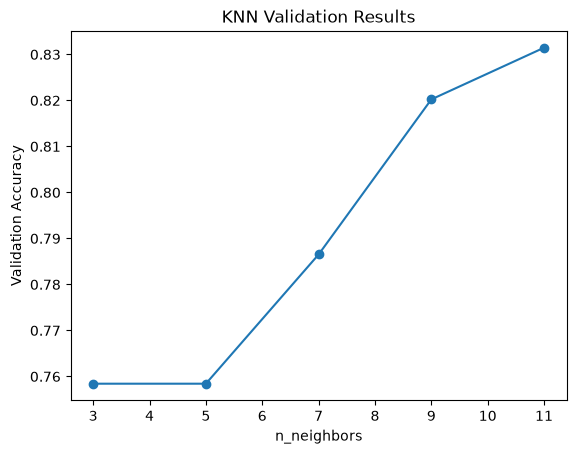

In [9]:
plt.plot(
    results_df["n_neighbors"],
    results_df["validation_accuracy"],
    marker="o"
)

plt.xlabel("n_neighbors")
plt.ylabel("Validation Accuracy")
plt.title("KNN Validation Results")
plt.show()

In [10]:
best_row = results_df.loc[
    results_df["validation_accuracy"].idxmax()
]

best_k = int(best_row["n_neighbors"])

print("Best n_neighbors:", best_k)
print(
    "Best validation accuracy:",
    best_row["validation_accuracy"]
)

Best n_neighbors: 11
Best validation accuracy: 0.8314606741573034


### Step 3: Evaluate the final model on the test set exactly once and report the score.

Now the tuning process is finished.

I already selected the best value of `n_neighbors` using the validation set.

I can now train the final model and use the test set for the final evaluation.

In [14]:
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])

final_model.fit(X_train, y_train)

test_predictions = final_model.predict(X_test)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print("Final Test Accuracy:", test_accuracy)

Final Test Accuracy: 0.770949720670391


## Classification Report

In [12]:
print(classification_report(  y_test,test_predictions))

              precision    recall  f1-score   support

           0       0.73      0.86      0.79       105
           1       0.73      0.55      0.63        74

    accuracy                           0.73       179
   macro avg       0.73      0.71      0.71       179
weighted avg       0.73      0.73      0.72       179



## Confusion Matrix

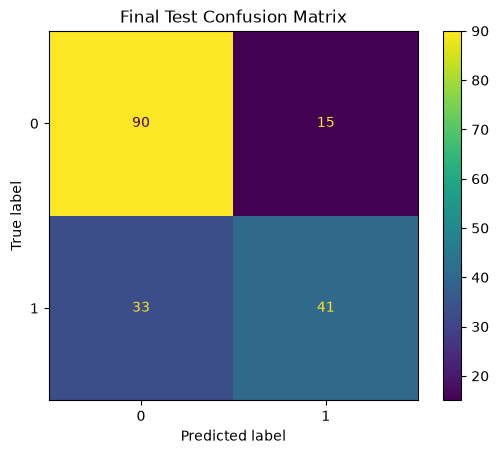

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions
)

plt.title("Final Test Confusion Matrix")
plt.show()

### Step 4: In Markdown, explain what would go wrong if you had tuned against the test set instead.

If I repeatedly checked the test score while trying different values of `n_neighbors`, I would use information from the test set to make model decisions.

For example, if I tried:

- `k = 3` on the test set
- `k = 5` on the test set
- `k = 7` on the test set
- `k = 9` on the test set

and selected the value with the highest test score, then I would be tuning the model against the test set.

The test set would no longer be completely unseen.

Because of this, the final test score could look better than the model's real performance on new data.

That is why:

- **Train** is used for learning.
- **Validation** is used for tuning.
- **Test** is used for the final evaluation.